# LightGBM Volatility Forecasting — Phase 6 Results

Trains LightGBM with custom QLIKE objective, Optuna HP tuning (purged k-fold CV), and SHAP feature importance.

**Sections:**
1. Load artifacts
2. QLIKE comparison vs baselines
3. Best hyperparameters
4. SHAP feature importance
5. Prediction distributions
6. Per-symbol performance
7. Time-series diagnostics
8. Summary table

In [1]:
import json
import sys
from pathlib import Path

# Add project root to path so theta imports work
sys.path.insert(0, str(Path("..").resolve()))

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import shap

DATA = Path("../data/processed")
SPLITS = DATA / "splits"
MODELS = DATA / "models"
PREDS = DATA / "predictions"

# Load artifacts
lgbm_preds = pl.read_parquet(PREDS / "lgbm.parquet")
baselines = pl.read_parquet(PREDS / "baselines.parquet")
train = pl.read_parquet(SPLITS / "train.parquet")
test = pl.read_parquet(SPLITS / "test.parquet")

with open(MODELS / "lgbm_best_params.json") as f:
    best_params = json.load(f)

shap_values = np.load(MODELS / "lgbm_shap_values.npy")

from theta.modeling.preprocessing import get_feature_cols
feature_cols = get_feature_cols(train)

print(f"LightGBM predictions: {len(lgbm_preds):,} rows")
print(f"Baseline predictions: {len(baselines):,} rows")
print(f"SHAP values shape: {shap_values.shape}")
print(f"Features: {len(feature_cols)}")

LightGBM predictions: 36,924 rows
Baseline predictions: 257,395 rows
SHAP values shape: (2000, 44)
Features: 44


## 2. QLIKE Comparison vs Baselines

In [2]:
def compute_qlike(y_true, y_pred):
    """QLIKE = mean(y/yhat - log(y/yhat) - 1)."""
    ratio = y_true / y_pred
    return float(np.mean(ratio - np.log(ratio) - 1))

def compute_mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))

# LightGBM QLIKE
y_lgbm = lgbm_preds["y_true"].to_numpy()
yhat_lgbm = lgbm_preds["y_pred"].to_numpy()
lgbm_qlike = compute_qlike(y_lgbm, yhat_lgbm)
lgbm_mse = compute_mse(y_lgbm, yhat_lgbm)

# Baseline QLIKEs
results = []
for model_name in baselines["model"].unique().sort().to_list():
    sub = baselines.filter(pl.col("model") == model_name)
    y = sub["y_true"].to_numpy()
    yhat = sub["y_pred"].to_numpy()
    results.append({
        "model": model_name,
        "qlike": compute_qlike(y, yhat),
        "mse": compute_mse(y, yhat),
        "n": len(sub),
    })

results.append({"model": "LightGBM", "qlike": lgbm_qlike, "mse": lgbm_mse, "n": len(lgbm_preds)})
results_df = pl.DataFrame(results).sort("qlike")

print("=" * 55)
print(f"{'Model':15s} {'QLIKE':>10s} {'MSE':>12s} {'n':>8s}")
print("-" * 55)
for row in results_df.iter_rows(named=True):
    print(f"{row['model']:15s} {row['qlike']:10.4f} {row['mse']:12.4f} {row['n']:8d}")
print("=" * 55)

# Improvement vs LogHAR
loghar_qlike = results_df.filter(pl.col("model") == "LogHAR")["qlike"][0]
pct_improvement = (loghar_qlike - lgbm_qlike) / loghar_qlike * 100
print(f"\nLightGBM vs LogHAR improvement: {pct_improvement:.1f}%")

Model                QLIKE          MSE        n
-------------------------------------------------------
LightGBM            0.0215       0.0026    36924
LogHAR              0.0259       0.0030    36811
HARQ                0.0263       0.0030    36924
SHAR                0.0264       0.0030    36924
LevHAR              0.0265       0.0030    36924
HAR                 0.0265       0.0030    36924
GARCH               0.2240       0.0359    36924
AR5                 0.3691       0.0284    35964

LightGBM vs LogHAR improvement: 17.0%


## 3. Best Hyperparameters

In [3]:
print("Best Optuna hyperparameters:")
print(json.dumps(best_params, indent=2))

Best Optuna hyperparameters:
{
  "num_leaves": 216,
  "learning_rate": 0.01352064869978298,
  "max_depth": 8,
  "min_child_samples": 26,
  "subsample": 0.9762204981169558,
  "colsample_bytree": 0.6963925128449335,
  "reg_alpha": 7.986698462509758,
  "reg_lambda": 4.153760622569633e-05,
  "num_boost_round": 738
}


## 4. SHAP Feature Importance

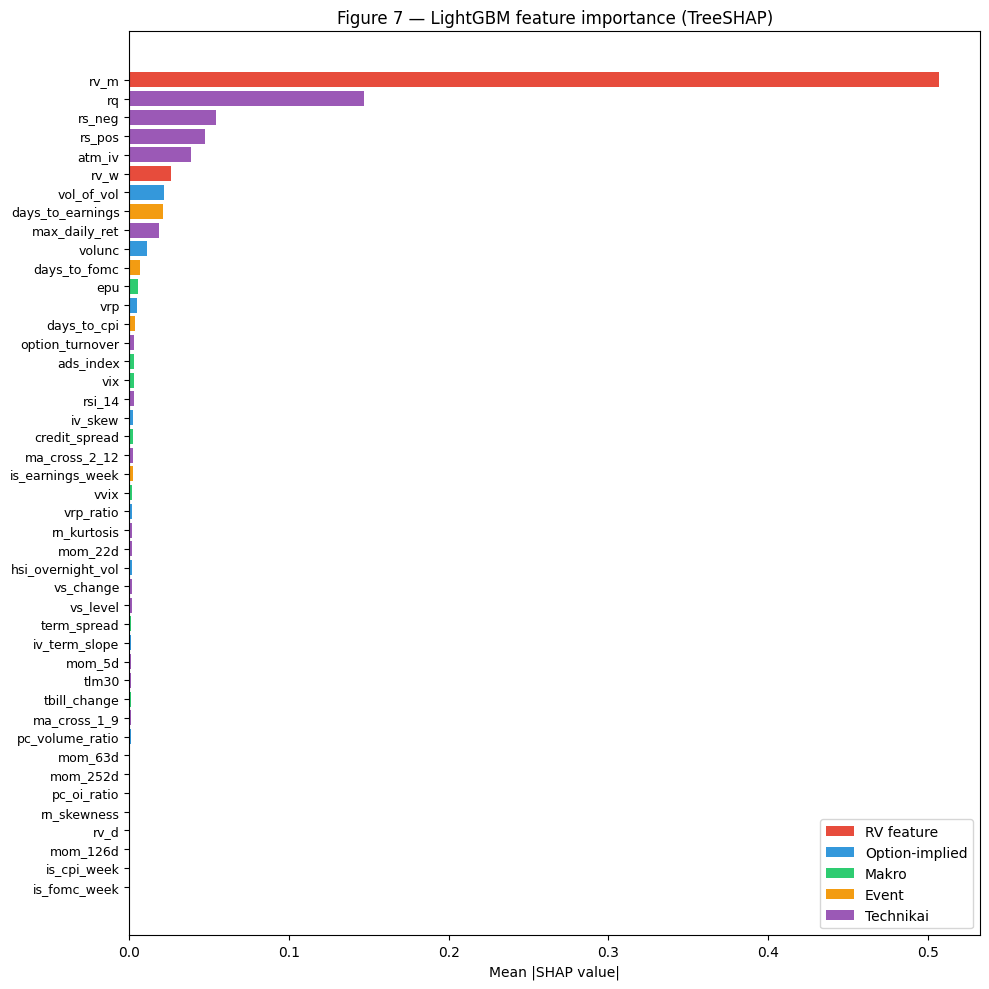


Top 10 features:
   1. rv_m                      0.5073
   2. rq                        0.1470
   3. rs_neg                    0.0545
   4. rs_pos                    0.0475
   5. atm_iv                    0.0387
   6. rv_w                      0.0260
   7. vol_of_vol                0.0215
   8. days_to_earnings          0.0210
   9. max_daily_ret             0.0187
  10. volunc                    0.0108


In [4]:
# Bar plot: mean |SHAP| per feature
importance = np.abs(shap_values).mean(axis=0)
ranking = sorted(zip(feature_cols, importance), key=lambda x: -x[1])

fig, ax = plt.subplots(figsize=(10, 10))
names = [r[0] for r in ranking]
vals = [r[1] for r in ranking]
colors = ["#e74c3c" if "rv_" in n else "#3498db" if "iv_" in n or "vr" in n or "skew" in n or "vol" in n
          else "#2ecc71" if "macro" in n or "vix" in n or "spread" in n or "epu" in n or "tbill" in n or "ads" in n or "hsi" in n
          else "#f39c12" if "fomc" in n or "earn" in n or "cpi" in n
          else "#9b59b6" for n in names]
ax.barh(range(len(names)), vals, color=colors)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Figure 7 — LightGBM feature importance (TreeSHAP)")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#e74c3c", label="RV feature"),
    Patch(facecolor="#3498db", label="Option-implied"),
    Patch(facecolor="#2ecc71", label="Makro"),
    Patch(facecolor="#f39c12", label="Event"),
    Patch(facecolor="#9b59b6", label="Technikai"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

# Top 10 table
print("\nTop 10 features:")
for i, (name, val) in enumerate(ranking[:10], 1):
    print(f"  {i:2d}. {name:25s} {val:.4f}")

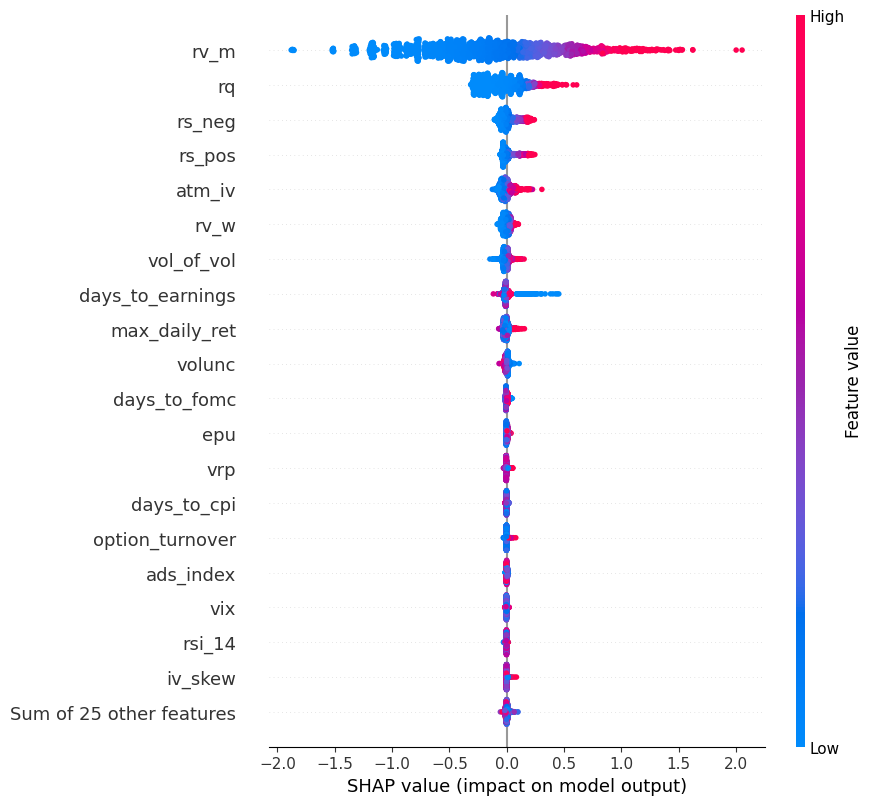

In [5]:
# SHAP beeswarm plot (top 20 features)
# Use test sample matching SHAP values
X_test = test.select(feature_cols).to_numpy()
n_shap = shap_values.shape[0]
rng = np.random.default_rng(42)
shap_idx = rng.choice(len(X_test), size=n_shap, replace=False)

explanation = shap.Explanation(
    values=shap_values,
    data=X_test[shap_idx],
    feature_names=feature_cols,
)
shap.plots.beeswarm(explanation, max_display=20, show=True)

## 5. Prediction Distributions

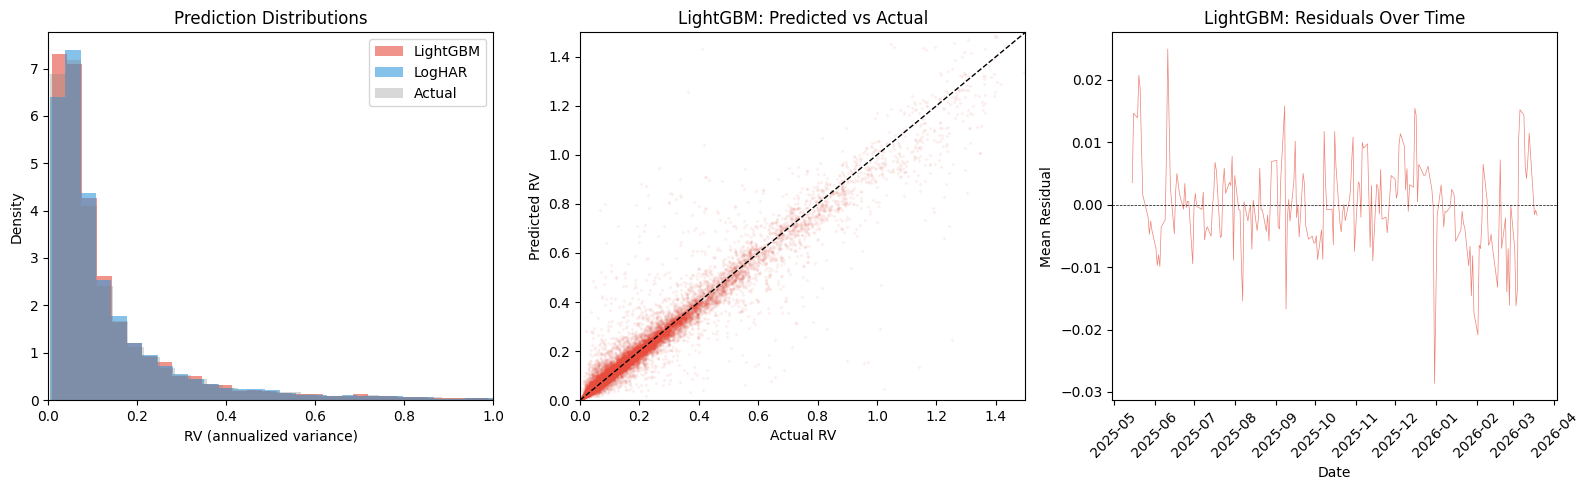

In [6]:
# LightGBM vs LogHAR predicted vs actual
loghar = baselines.filter(pl.col("model") == "LogHAR")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram of predictions
axes[0].hist(yhat_lgbm, bins=80, alpha=0.6, label="LightGBM", color="#e74c3c", density=True)
axes[0].hist(loghar["y_pred"].to_numpy(), bins=80, alpha=0.6, label="LogHAR", color="#3498db", density=True)
axes[0].hist(y_lgbm, bins=80, alpha=0.3, label="Actual", color="gray", density=True)
axes[0].set_xlim(0, 1.0)
axes[0].set_xlabel("RV (annualized variance)")
axes[0].set_ylabel("Density")
axes[0].set_title("Prediction Distributions")
axes[0].legend()

# Scatter: predicted vs actual
axes[1].scatter(y_lgbm, yhat_lgbm, alpha=0.05, s=2, color="#e74c3c")
axes[1].plot([0, 2], [0, 2], "k--", lw=1)
axes[1].set_xlim(0, 1.5)
axes[1].set_ylim(0, 1.5)
axes[1].set_xlabel("Actual RV")
axes[1].set_ylabel("Predicted RV")
axes[1].set_title("LightGBM: Predicted vs Actual")

# Residuals over time
merged = lgbm_preds.with_columns(
    (pl.col("y_pred") - pl.col("y_true")).alias("residual")
).sort("date")
daily_resid = merged.group_by("date").agg(pl.col("residual").mean())
dates = daily_resid.sort("date")["date"].to_numpy()
resids = daily_resid.sort("date")["residual"].to_numpy()
axes[2].plot(dates, resids, lw=0.5, color="#e74c3c", alpha=0.7)
axes[2].axhline(0, color="k", lw=0.5, ls="--")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Mean Residual")
axes[2].set_title("LightGBM: Residuals Over Time")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Per-Symbol Performance

LightGBM wins: 134/192 symbols (70%)


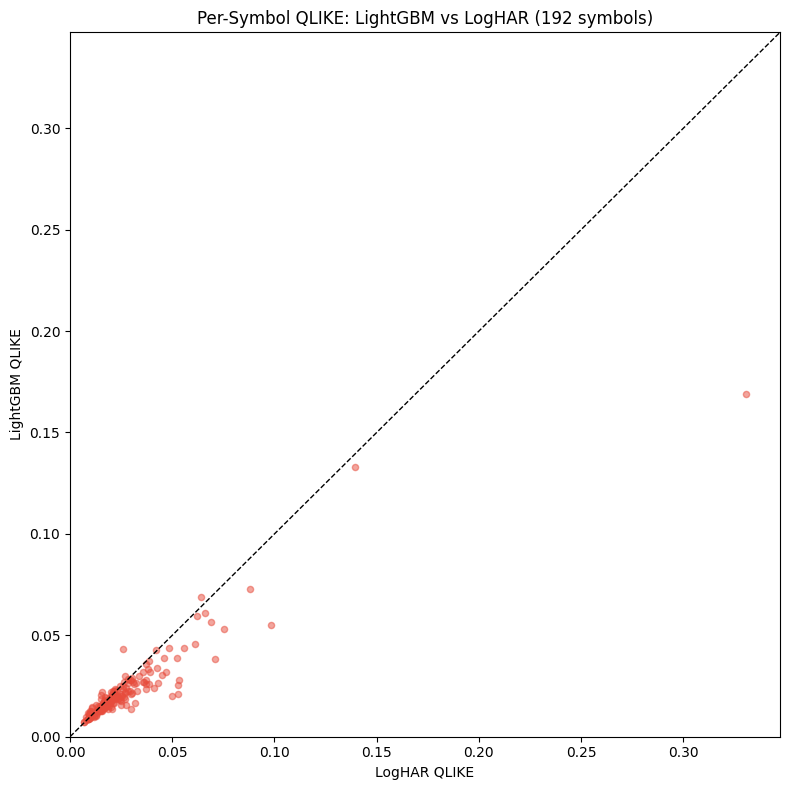

In [7]:
# Per-symbol QLIKE: LightGBM vs LogHAR
def symbol_qlike(df):
    """Compute QLIKE per symbol."""
    results = {}
    for sym in df["symbol"].unique().sort().to_list():
        sub = df.filter(pl.col("symbol") == sym)
        y = sub["y_true"].to_numpy()
        yhat = sub["y_pred"].to_numpy()
        ratio = y / yhat
        results[sym] = float(np.mean(ratio - np.log(ratio) - 1))
    return results

lgbm_sym = symbol_qlike(lgbm_preds)
loghar_sym = symbol_qlike(loghar)

# Scatter: LightGBM vs LogHAR per symbol
common = sorted(set(lgbm_sym) & set(loghar_sym))
lgbm_vals = [lgbm_sym[s] for s in common]
loghar_vals = [loghar_sym[s] for s in common]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(loghar_vals, lgbm_vals, alpha=0.5, s=20, color="#e74c3c")
lim = max(max(lgbm_vals), max(loghar_vals)) * 1.05
ax.plot([0, lim], [0, lim], "k--", lw=1)
ax.set_xlabel("LogHAR QLIKE")
ax.set_ylabel("LightGBM QLIKE")
ax.set_title(f"Per-Symbol QLIKE: LightGBM vs LogHAR ({len(common)} symbols)")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)

# Count wins
wins = sum(1 for l, h in zip(lgbm_vals, loghar_vals) if l < h)
print(f"LightGBM wins: {wins}/{len(common)} symbols ({wins/len(common)*100:.0f}%)")
plt.tight_layout()
plt.show()

## 7. Time-Series: LightGBM vs LogHAR for Selected Symbols

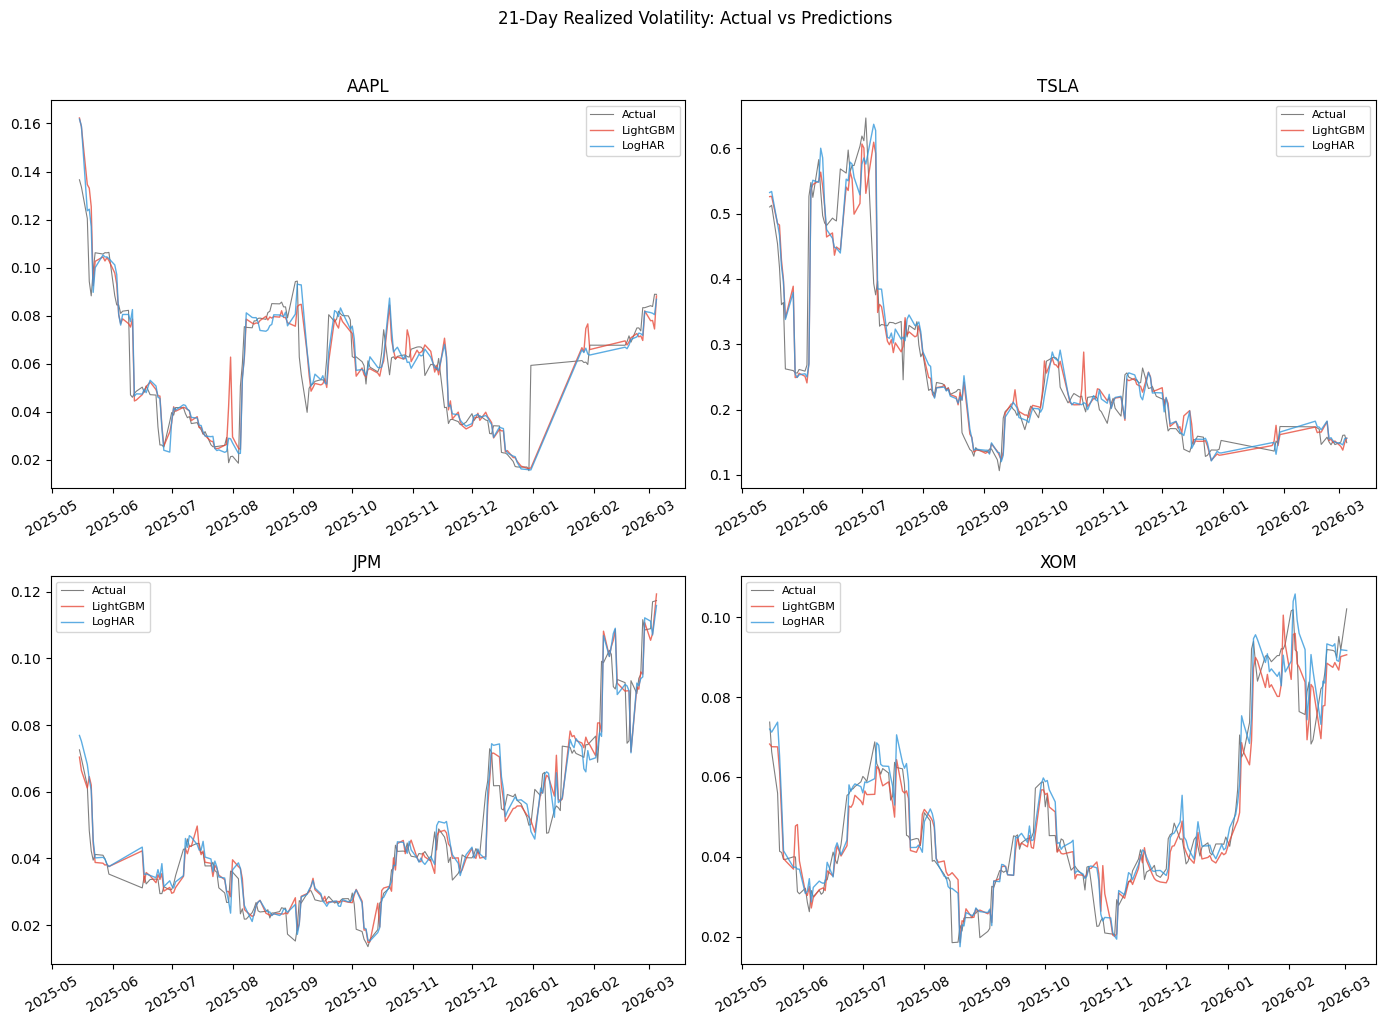

In [8]:
# Time-series for 4 representative symbols
symbols = ["AAPL", "TSLA", "JPM", "XOM"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, sym in zip(axes.flatten(), symbols):
    lgbm_s = lgbm_preds.filter(pl.col("symbol") == sym).sort("date")
    loghar_s = loghar.filter(pl.col("symbol") == sym).sort("date")

    if len(lgbm_s) == 0:
        ax.set_title(f"{sym} — no data")
        continue

    dates = lgbm_s["date"].to_numpy()
    ax.plot(dates, lgbm_s["y_true"].to_numpy(), "k-", lw=0.8, alpha=0.5, label="Actual")
    ax.plot(dates, lgbm_s["y_pred"].to_numpy(), "-", lw=1, color="#e74c3c", alpha=0.8, label="LightGBM")
    if len(loghar_s) > 0:
        ax.plot(loghar_s["date"].to_numpy(), loghar_s["y_pred"].to_numpy(), "-", lw=1, color="#3498db", alpha=0.8, label="LogHAR")
    ax.set_title(sym)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle("21-Day Realized Volatility: Actual vs Predictions", y=1.02)
plt.tight_layout()
plt.show()

## 8. Summary Table (for dissertation)

In [9]:
# R2_OOS (Gu/Kelly/Xiu): 1 - sum((y-yhat)^2) / sum((y-y_bar_train)^2)
with open(SPLITS / "scaler_stats.json") as f:
    scaler = json.load(f)
train_mean_rv = scaler["__train_mean_rv__"]

def r2_oos(y_true, y_pred, train_mean):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - train_mean) ** 2)
    return 1 - ss_res / ss_tot

# Final summary
print("=" * 70)
print(f"{'Model':15s} {'QLIKE':>10s} {'MSE':>12s} {'R2_OOS':>10s} {'n':>8s}")
print("-" * 70)

all_models = []
for row in results_df.iter_rows(named=True):
    model_name = row["model"]
    if model_name == "LightGBM":
        r2 = r2_oos(y_lgbm, yhat_lgbm, train_mean_rv)
    else:
        sub = baselines.filter(pl.col("model") == model_name)
        r2 = r2_oos(sub["y_true"].to_numpy(), sub["y_pred"].to_numpy(), train_mean_rv)
    print(f"{model_name:15s} {row['qlike']:10.4f} {row['mse']:12.4f} {r2:10.4f} {row['n']:8d}")
    all_models.append({**row, "r2_oos": r2})

print("=" * 70)
print(f"\ntrain_mean_rv = {train_mean_rv:.4f}")
print(f"LogHAR baseline QLIKE = {loghar_qlike:.4f}")
print(f"LightGBM QLIKE = {lgbm_qlike:.4f}")
print(f"Improvement: {pct_improvement:.1f}%")

Model                QLIKE          MSE     R2_OOS        n
----------------------------------------------------------------------
LightGBM            0.0215       0.0026     0.9404    36924
LogHAR              0.0259       0.0030     0.9310    36811
HARQ                0.0263       0.0030     0.9302    36924
SHAR                0.0264       0.0030     0.9303    36924
LevHAR              0.0265       0.0030     0.9303    36924
HAR                 0.0265       0.0030     0.9303    36924
GARCH               0.2240       0.0359     0.1721    36924
AR5                 0.3691       0.0284     0.3367    35964

train_mean_rv = 0.1748
LogHAR baseline QLIKE = 0.0259
LightGBM QLIKE = 0.0215
Improvement: 17.0%
